In [1]:
from pipeline import  run_full_experiment

In [2]:
from preprocessing import cleaning_text
print(cleaning_text("This is a great place and I loved the food!"))

['great', 'place', 'love', 'food']


In [3]:
%time results = run_full_experiment(csv_path = 'YelpData.csv')

C:\Users\alkan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Sistem belirtilen dosyayı bulamıyor
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\alkan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\alkan\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alkan\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\alkan\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(e

Fitting 3 folds for each of 20 candidates, totalling 60 fits
CPU times: total: 23min 41s
Wall time: 17min 41s


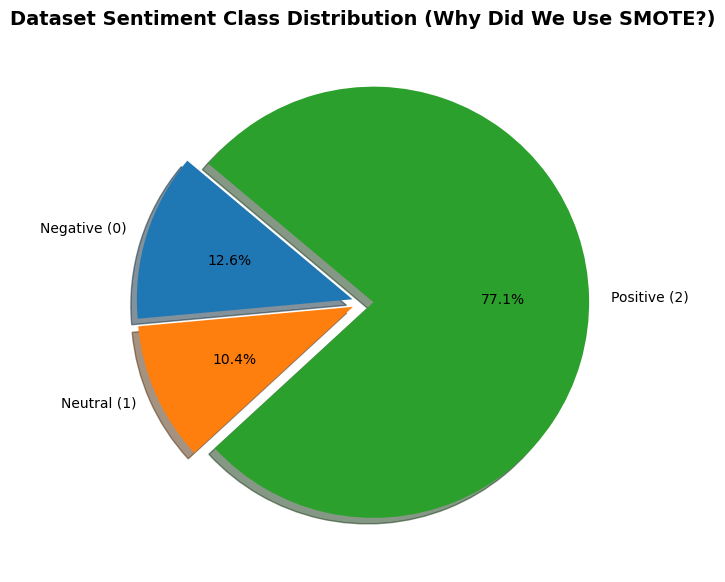

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


all_labels = pd.concat([results['y_train'], results['y_test']])
class_counts = all_labels.value_counts().sort_index() # 0, 1, 2 

label_names= ['Negative (0)', 'Neutral (1)', 'Positive (2)']

plt.figure(figsize=(7, 7))
plt.pie(class_counts, labels=label_names, autopct='%1.1f%%',
 startangle=140, shadow=True, explode=(0.05, 0.05, 0.05))
plt.title("Dataset Sentiment Class Distribution (Why Did We Use SMOTE?)", fontsize=14, fontweight='bold')
plt.show()

In [5]:
# Özet: Best Base Model Information
best_info = results["best_info"]
best_score = results["best_score"]

print("Best Combination :", best_info["comb_name"])
print("Best Model       :", best_info["model_name"])
print("Weighted F1      :", round(best_score, 4))

Best Combination : 4. Hybrid + SMOTE
Best Model       : XGBoost
Weighted F1      : 0.8361


In [6]:
# Sınıf bazlı metrikler: classification report
from pprint import pprint

print("\nClassification Report (base best model):\n")
print(best_info["classification_report"])


Classification Report (base best model):

              precision    recall  f1-score   support

           0     0.6885    0.7174    0.7026       499
           1     0.3594    0.3889    0.3735       414
           2     0.9286    0.9120    0.9202      3067

    accuracy                         0.8332      3980
   macro avg     0.6588    0.6728    0.6655      3980
weighted avg     0.8393    0.8332    0.8361      3980



In [7]:
# Hyperparameter Search Results (RandomizedSearchCV)

tuned_search = results.get("tuned_search")

if tuned_search is None:
    print("Tuning henüz çalışmadı veya en iyi model Hybrid+SMOTE XGBoost değildi.")
else:
    print("CV Weighted F1 (best):", round(tuned_search.best_score_, 4))
    print("\nBest Params:")
    for k, v in tuned_search.best_params_.items():
        print(f"  {k}: {v}")

CV Weighted F1 (best): 0.8397

Best Params:
  model__subsample: 1.0
  model__n_estimators: 300
  model__max_depth: 9
  model__learning_rate: 0.05
  model__colsample_bytree: 0.9


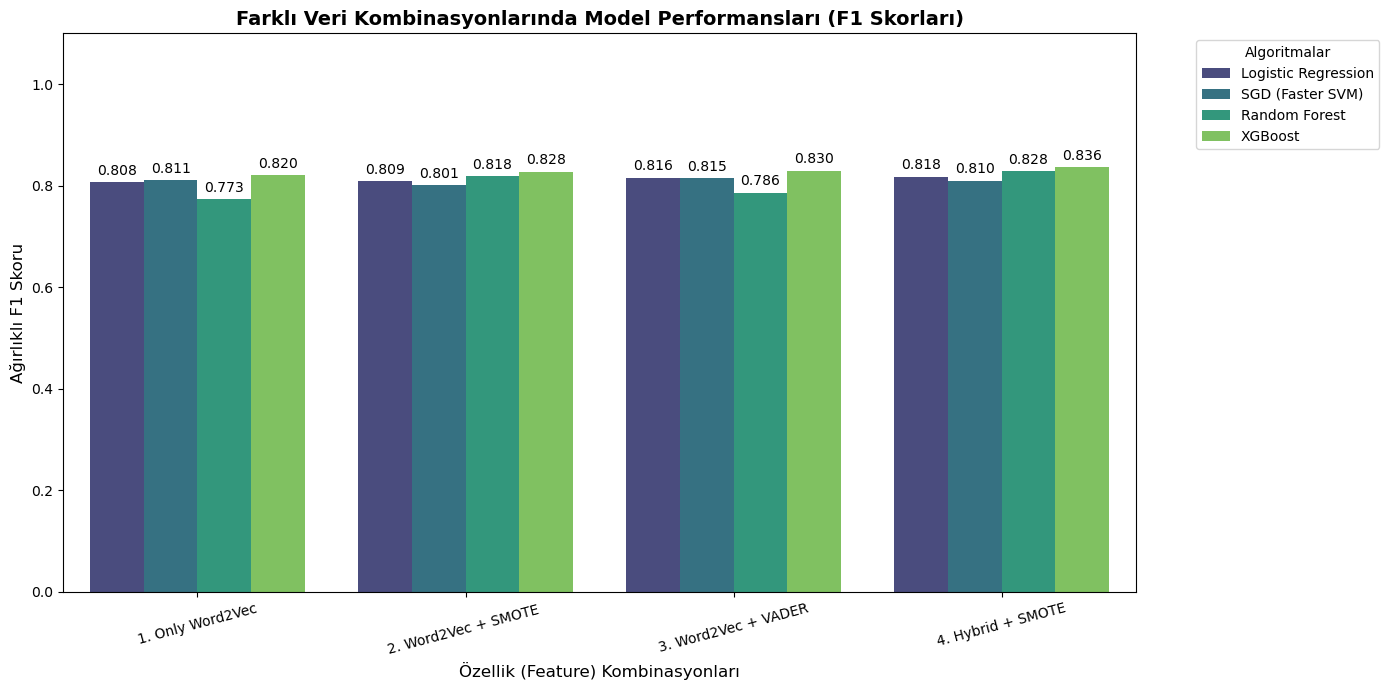

In [8]:
# 'results' listesindeki verileri Pandas DataFrame'e çevirelim
deney_verileri = []
for res in results['results']:
    # NaN (Hata almış) olanları grafikte göstermemek için filtreleyebiliriz
    if pd.notna(res.f1_score): 
        deney_verileri.append({
            'Model': res.model_name,
            'Kombinasyon': res.combination,
            'F1_Skoru': res.f1_score
        })

df_sonuclar = pd.DataFrame(deney_verileri)

# Grafiği çizdirelim
plt.figure(figsize=(14, 7)) # Değerler sığsın diye grafiği biraz daha genişlettik

# sns.barplot'u 'ax' adlı bir değişkene atıyoruz ki daha sonra üzerine işlem yapabilelim
ax = sns.barplot(data=df_sonuclar, x='Kombinasyon', y='F1_Skoru', hue='Model', palette='viridis')

# SÜTUNLARIN ÜZERİNE DEĞERLERİ YAZDIRMA KISMI
for container in ax.containers:
    # fmt='%.3f' ile virgülden sonra 3 basamak gösteriyoruz (örn: 0.842)
    # padding=3 ile sayının sütunla arasına hafif bir boşluk bırakıyoruz
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

plt.title('Farklı Veri Kombinasyonlarında Model Performansları (F1 Skorları)', fontsize=14, fontweight='bold')
plt.xlabel('Özellik (Feature) Kombinasyonları', fontsize=12)
plt.ylabel('Ağırlıklı F1 Skoru', fontsize=12)

# X eksenindeki yazıları daha okunaklı yapmak için hafif eğiyoruz
plt.xticks(rotation=15) 
# Değerler en üstte kesilmesin diye Y ekseninin tavanını biraz yükseltebiliriz
plt.ylim(0, 1.1) 

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Algoritmalar')
plt.tight_layout()
plt.show()

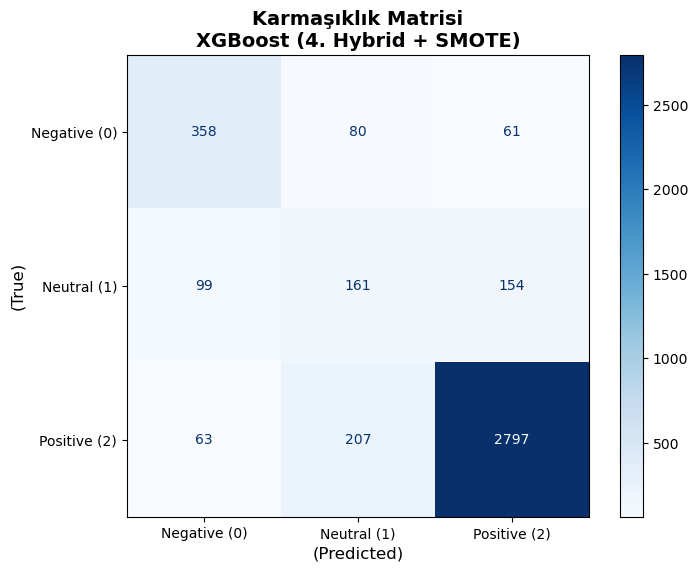

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# En iyi modelin test sonuçlarını alıyoruz
en_iyi_y_test = results['best_info']['y_test']
en_iyi_tahminler = results['best_info']['preds']
en_iyi_model_ismi = results['best_info']['model_name']
en_iyi_kombinasyon = results['best_info']['comb_name']

# Karmaşıklık Matrisini hesapla
cm = confusion_matrix(en_iyi_y_test, en_iyi_tahminler)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

# Görselleştir
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title(f"Karmaşıklık Matrisi\n{en_iyi_model_ismi} ({en_iyi_kombinasyon})", 
          fontsize=14, fontweight='bold')
plt.xlabel("(Predicted)", fontsize=12)
plt.ylabel("(True)", fontsize=12)
plt.show()